## Section 7: Classical Model Selection and Training

In this section, we will:
- Select and train **Classical Model 1** 
- Select and train **Classical Model 2** 
- Provide justification for model choices
- Train models and monitor performance on testing set

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# decision tree regressor ?
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# dataset is small enough for gridsearchcv
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('../data/final_split/X_train_nn.csv')
X_test = pd.read_csv('../data/final_split/X_test_nn.csv')
y_train = pd.read_csv('../data/final_split/y_train_nn.csv').values.ravel()
y_test = pd.read_csv('../data/final_split/y_test_nn.csv').values.ravel()

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Testing set:    {X_test.shape[0]} samples")

Training set:   2183 samples
Testing set:    468 samples


### Saving Baseline Classical Models for later comparison

In [15]:
print("Baseline Models")
#Random Forest Baseline
baseline_rf = RandomForestRegressor(random_state=42)
baseline_rf.fit(X_train, y_train)
baseline_rf_predictions = baseline_rf.predict(X_test)
baseline_rf_mae = mean_absolute_error(y_test, baseline_rf_predictions)
print(f"Random Forest abseline MAE: {baseline_rf_mae:.4f}")

joblib.dump(baseline_rf, '../models/classical_baseline/baseline_rf_model.pkl')

#XGBoost Baseline
baseline_xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
baseline_xgb.fit(X_train, y_train)
baseline_xgb_predictions = baseline_xgb.predict(X_test)
baseline_xgb_mae = mean_absolute_error(y_test, baseline_xgb_predictions)
print(f"XGBoost baseline MAE: {baseline_xgb_mae:.4f}")

joblib.dump(baseline_xgb, '../models/classical_baseline/baseline_xgb_model.pkl')

print("\nModels saved as 'baseline_rf_model.pkl' and 'baseline_xgb_model.pkl' in the '../models/classical_baseline/' directory")

Baseline Models
Random Forest abseline MAE: 0.8902
XGBoost baseline MAE: 0.9035

Models saved as 'baseline_rf_model.pkl' and 'baseline_xgb_model.pkl' in the '../models/classical_baseline/' directory


### Classical Model 1: Random Forest Regressor
Justification: The Dataset we have has a lot of features that are engineered. Random forest has a bagging ensemble method that can handle non=linear relationships well without too much hyperparameter tuning so it can help reduce potential overfitting by averaging out the multiple independent decision trees it will produce.

In [16]:
#tuning the RF regressor

rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}

# automates the training and validation
rf_grid = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=rf_param_grid, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

# get the best model
best_rf_model = rf_grid.best_estimator_
print("\nBest Random Forest Parameters:", rf_grid.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Random Forest Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [17]:
print(f"Random Forest CV Validation MAE: {abs(rf_grid.best_score_):.4f}")

Random Forest CV Validation MAE: 0.9298


### Classical Model 2: XGBoost
Justification: Similar to the justification for the random forest, the one here is affecting the engineered features by instead actively reducing the bias. XGboost has a boosting ensemble technique that makes each new tree try to correct the errors of the previous trees. It also includes built in regularization

Furtermore, its high effectiveness on tabular data might capture the scaling patterns of the CR of monsters better than the bagging ensemble.

In [18]:
# tunes the XGBoost, same steps as model 1

xgb_param_grid = {'n_estimators': [100, 250], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'subsample': [0.8, 1.0]}
xgb_grid = GridSearchCV(estimator=XGBRegressor(random_state=42, objective='reg:squarederror'), param_grid=xgb_param_grid, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1, verbose=1)


xgb_grid.fit(X_train, y_train)

best_xgb_model = xgb_grid.best_estimator_
print("\nBest XGBoost Parameters:", xgb_grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 250, 'subsample': 0.8}


In [19]:
print(f"XGBoost CV Validation MAE: {abs(xgb_grid.best_score_):.4f}")

XGBoost CV Validation MAE: 0.9055


### FEATURE IMPORTANCE of both models

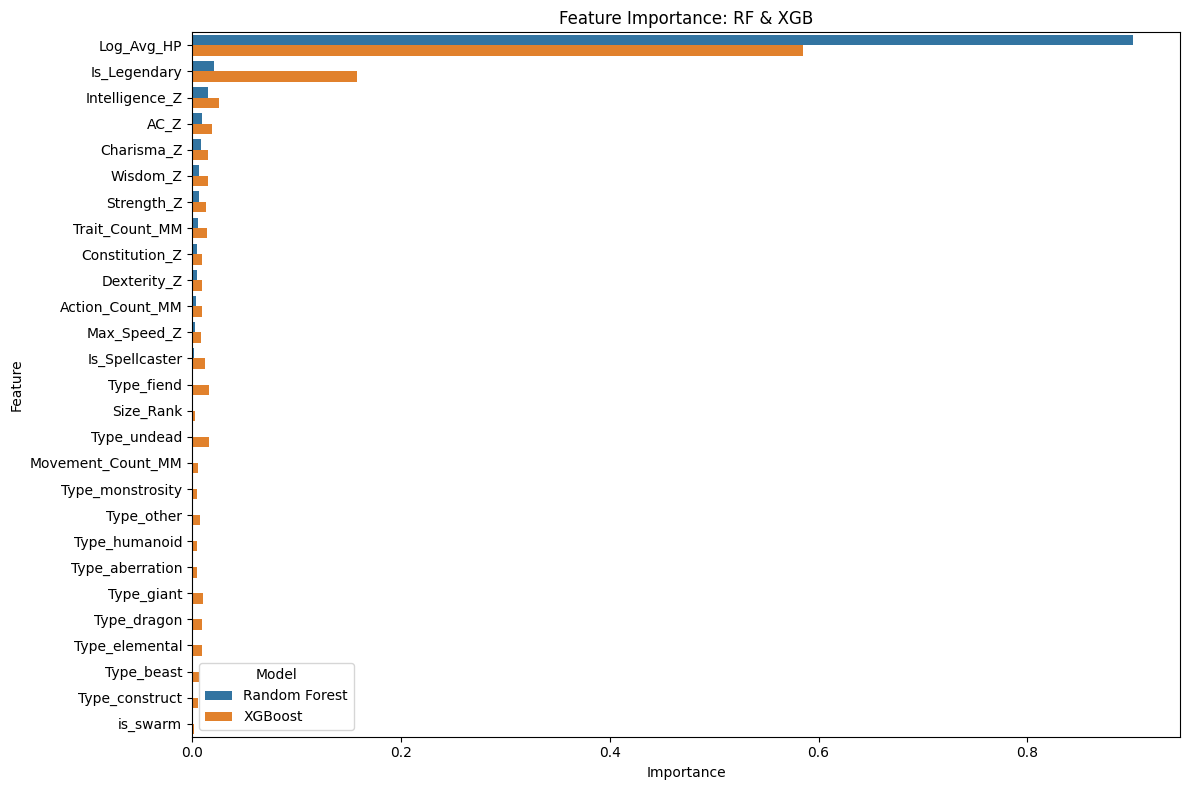

In [20]:

rf_importances = best_rf_model.feature_importances_
xgb_importances = best_xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
})

importance_melted = importance_df.melt(id_vars='Feature', var_name='Model', value_name='Importance')
importance_melted = importance_melted.sort_values(by=['Model', 'Importance'], ascending=[True, False])

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_melted, x='Importance', y='Feature', hue='Model')
plt.title('Feature Importance: RF & XGB')
plt.tight_layout()
plt.show()

### Final Evaluation on Test Set
Now that both models have been tuned via Cross-Validation on the training set, we will evaluate their final performance on the completely unseen testing set to determine which classical architecture best predicts Challenge Rating.

Random Forest
  MAE:  0.8819
  RMSE: 1.3562
  R²:   0.9511



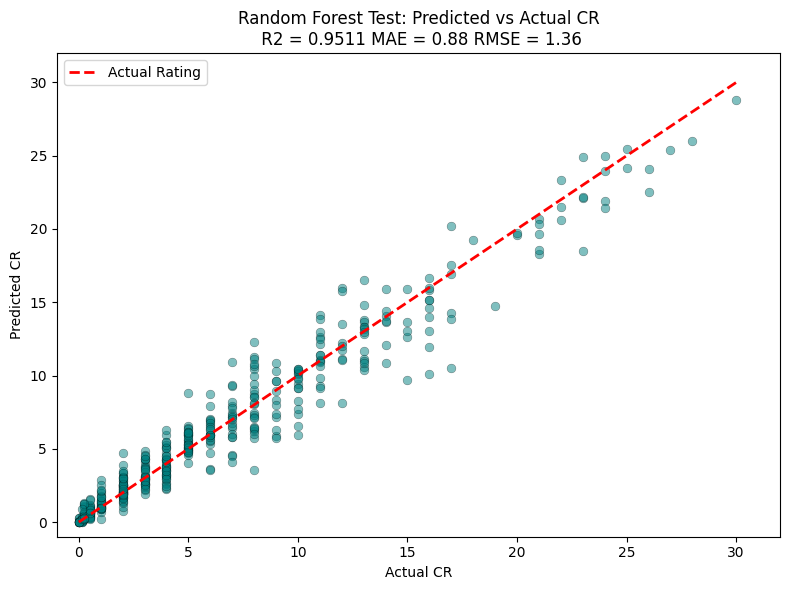

XGBoost
  MAE:  0.8531
  RMSE: 1.3279
  R²:   0.9531



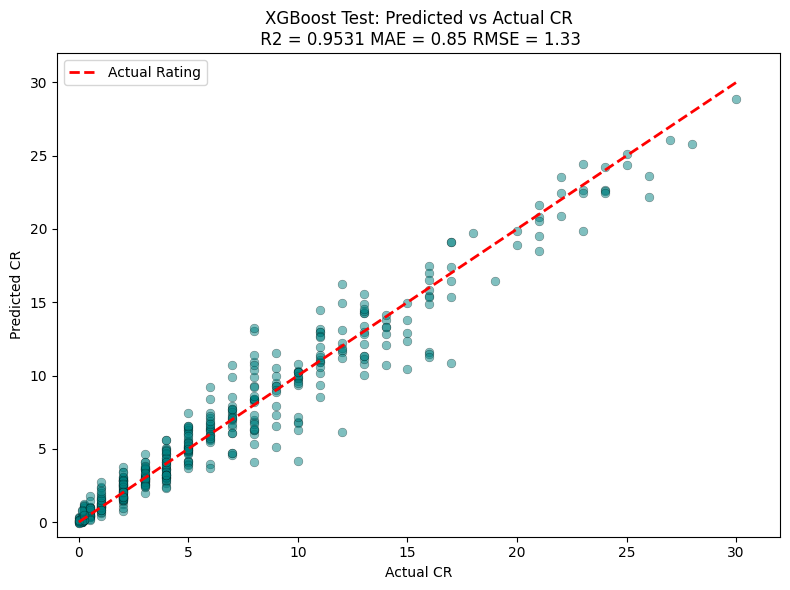

Better Model: XGBoost


In [21]:
#test set evaluation

rf_test_predictions = best_rf_model.predict(X_test)
xgb_test_predictions = best_xgb_model.predict(X_test)

def evaluate_and_plot_test(y_true, y_predictions, model_name):

    mae = mean_absolute_error(y_true, y_predictions)
    rmse = np.sqrt(mean_squared_error(y_true, y_predictions))
    r2 = r2_score(y_true, y_predictions)
    
    print(f"{model_name}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}\n")
    
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    #scatter plot
    ax.scatter(y_true, y_predictions, alpha=0.5, color='teal', edgecolors='black', linewidth=0.3, s=40)
    ax.plot([0, 30], [0, 30], 'r--', linewidth=2, label='Actual Rating')
    
    ax.set_title(f'{model_name} Test: Predicted vs Actual CR\n R2 = {r2:.4f} MAE = {mae:.2f} RMSE = {rmse:.2f}')
    
    ax.set_xlabel('Actual CR')
    ax.set_ylabel('Predicted CR')

    #Max possible CR is 30
    ax.set_xlim(-1, 32)
    ax.set_ylim(-1, 32)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

#call plots
evaluate_and_plot_test(y_test, rf_test_predictions, "Random Forest")
evaluate_and_plot_test(y_test, xgb_test_predictions, "XGBoost")

correct_predictions = xgb_test_predictions if mean_absolute_error(y_test, xgb_test_predictions) < mean_absolute_error(y_test, rf_test_predictions) else rf_test_predictions
# we base the winner on the lower MAE - we only look at MAE because we find it to be the most pure form of error

winner_name = "XGBoost" if correct_predictions is xgb_test_predictions else "Random Forest"
print(f"Better Model: {winner_name}")

### Error Analysis

After evaluating on the test set, produce the following:

1. A residuals plot - predicted minus actual CR on the y-axis, actual CR on the x-axis, with a horizontal line at zero
2. A histogram of residuals to check whether errors are roughly symmetric
3. A table of the top 15 largest prediction errors (actual CR, predicted CR, absolute error)
4. A breakdown of mean absolute error grouped by CR tier (0–1, 1–5, 5–10, 10–20, 20+) to show where the model struggles most
5. A written markdown interpretation covering: what the residual pattern shows, which CR tier has the highest error and why, and whether there is any systematic bias (check the mean residual)

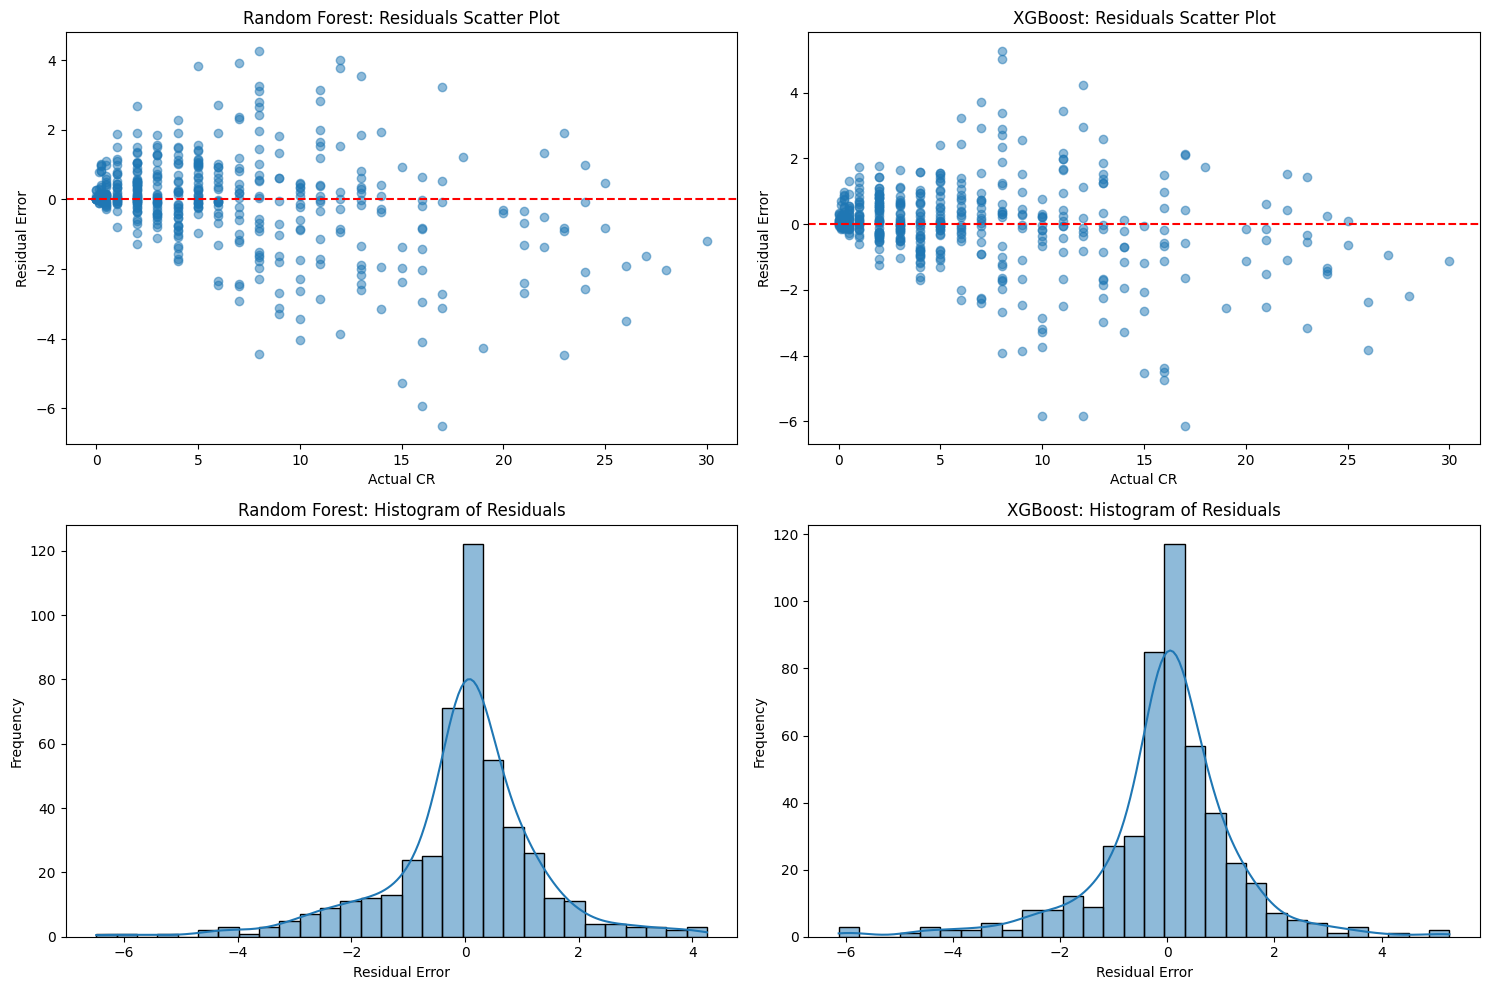


Random Forest: 10 Largest Prediction Errors


,Actual_CR,RF_Prediction,RF_Abs_Error
463,17.0,10.51,6.49
450,16.0,10.08,5.92
199,15.0,9.72,5.28
223,23.0,18.53,4.47
20,8.0,3.55,4.45
280,19.0,14.73,4.27
431,8.0,12.26,4.26
416,16.0,11.92,4.09
339,10.0,5.96,4.04
144,12.0,16.00,4.00



XGBoost: 10 Largest Prediction Errors


,Actual_CR,XGB_Prediction,XGB_Abs_Error
463,17.0,10.87,6.13
250,12.0,6.15,5.85
183,10.0,4.15,5.85
431,8.0,13.27,5.27
176,8.0,13.02,5.02
450,16.0,11.26,4.74
199,15.0,10.46,4.54
416,16.0,11.49,4.51
133,16.0,11.62,4.38
206,12.0,16.23,4.23



Mean Absolute Error by CR Tier


,CR_Tier,RF MAE,XGB MAE
0,0-1,0.2591,0.2818
1,1-5,0.6513,0.6047
2,5-10,1.3023,1.3232
3,10-20,1.6422,1.5841
4,20+,1.5657,1.2823



Overall Mean Absolute Error - Random Forest: 0.8819
Overall Mean Absolute Error - XGBoost: 0.8531


In [22]:
# 
rf_predictions = best_rf_model.predict(X_test)
xgb_predictions = best_xgb_model.predict(X_test)

results_df = pd.DataFrame({
    'Actual_CR': y_test, 
    'RF_Prediction': rf_predictions, 
    'XGB_Prediction': xgb_predictions,
    'RF_Residual': rf_predictions - y_test,
    'XGB_Residual': xgb_predictions - y_test,
    'RF_Abs_Error': np.abs(rf_predictions - y_test),
    'XGB_Abs_Error': np.abs(xgb_predictions - y_test)
})

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#RF scatter
axes[0, 0].scatter(results_df['Actual_CR'], results_df['RF_Residual'], alpha=0.5)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Random Forest: Residuals Scatter Plot')
axes[0, 0].set_xlabel('Actual CR')
axes[0, 0].set_ylabel('Residual Error')

# XGBoost
axes[0, 1].scatter(results_df['Actual_CR'], results_df['XGB_Residual'], alpha=0.5)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('XGBoost: Residuals Scatter Plot')
axes[0, 1].set_xlabel('Actual CR')
axes[0, 1].set_ylabel('Residual Error')

# Rf Historgam
sns.histplot(results_df['RF_Residual'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Random Forest: Histogram of Residuals')
axes[1, 0].set_xlabel('Residual Error')
axes[1, 0].set_ylabel('Frequency')

# XGBoost
sns.histplot(results_df['XGB_Residual'], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('XGBoost: Histogram of Residuals')
axes[1, 1].set_xlabel('Residual Error')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Top 10 Largest Prediction Errors
print("\nRandom Forest: 10 Largest Prediction Errors")
display(results_df[['Actual_CR', 'RF_Prediction', 'RF_Abs_Error']].sort_values(by='RF_Abs_Error', ascending=False).head(10).round(2))

print("\nXGBoost: 10 Largest Prediction Errors")
display(results_df[['Actual_CR', 'XGB_Prediction', 'XGB_Abs_Error']].sort_values(by='XGB_Abs_Error', ascending=False).head(10).round(2))

#Tiers based on actual dnd mechanics scaling
bins = [-1, 1, 5, 10, 20, 35] 
labels = ['0-1', '1-5', '5-10', '10-20', '20+']
results_df['CR_Tier'] = pd.cut(results_df['Actual_CR'], bins=bins, labels=labels, right=True)

#calculate MAE for both models
tier_mae = results_df.groupby('CR_Tier', observed=False)[['RF_Abs_Error', 'XGB_Abs_Error']].mean().reset_index()
tier_mae.rename(columns={'RF_Abs_Error': 'RF MAE', 'XGB_Abs_Error': 'XGB MAE'}, inplace=True)

print("\nMean Absolute Error by CR Tier")
display(tier_mae.round(4))

#Overall MAE
rf_overall_mae = results_df['RF_Abs_Error'].mean()
xgb_overall_mae = results_df['XGB_Abs_Error'].mean()
print(f"\nOverall Mean Absolute Error - Random Forest: {rf_overall_mae:.4f}")
print(f"Overall Mean Absolute Error - XGBoost: {xgb_overall_mae:.4f}")

### Error Analysis Interpretation

The residuals plot indicates strong predictive accuracy for lower (0-5) CR monsters, clustering near zero. As CR increases though, the residual spread widens, showing increased variance when predicting highly complex boss monsters.

A potential reason as to why higher CR tier exhibits the higher MAE is that High-CR monsters also rely on unique, hard-to-quantify traits (e.g., Mythic Actions, unique spellcasting) rather than purely physical stats.

In [23]:
#percentage of predictions within 1 Challenge Rating (CR)
rf_within_1 = np.mean(np.abs(rf_predictions - y_test) <= 1)
xgb_within_1 = np.mean(np.abs(xgb_predictions - y_test) <= 1)

print(f"Random Forest - Predicted within 1 CR: {rf_within_1:.4%}")
print(f"XGBoost - Predcited within 1 CR: {xgb_within_1:.4%}")

Random Forest - Predicted within 1 CR: 68.8034%
XGBoost - Predcited within 1 CR: 71.3675%


### Baseline Comparison

In [24]:
# Direct Comparison: Baseline vs. Tuned Performance
print("Tuning Impact on MAE")

# Random Forest Comparison
rf_improvement = baseline_rf_mae - rf_overall_mae
print(f"Random Forest Baseline MAE: {baseline_rf_mae:.4f}")
print(f"Random Forest Tuned MAE: {rf_overall_mae:.4f}")
print(f"Total Improvement: {rf_improvement:.4f} " + 
      ("(Worse after tuning)" if rf_improvement < 0 else "(Better after tuning)"))

print("-" * 40)

# XGBoost Comparison
xgb_improvement = baseline_xgb_mae - xgb_overall_mae
print(f"XGBoost Baseline MAE: {baseline_xgb_mae:.4f}")
print(f"XGBoost Tuned MAE: {xgb_overall_mae:.4f}")
print(f"Total Improvement: {xgb_improvement:.4f} " + 
      ("(Worse after tuning)" if xgb_improvement < 0 else "(Better after tuning)"))

Tuning Impact on MAE
Random Forest Baseline MAE: 0.8902
Random Forest Tuned MAE: 0.8819
Total Improvement: 0.0083 (Better after tuning)
----------------------------------------
XGBoost Baseline MAE: 0.9035
XGBoost Tuned MAE: 0.8531
Total Improvement: 0.0504 (Better after tuning)


In [25]:
joblib.dump(best_rf_model, '../models/classical_tuned/tuned_rf_model.pkl')
joblib.dump(best_xgb_model, '../models/classical_tuned/tuned_xgb_model.pkl')
print("\nTuned models saved as 'tuned_rf_model.pkl' and 'tuned_xgb_model.pkl' in the '../models/classical_tuned/' directory")


Tuned models saved as 'tuned_rf_model.pkl' and 'tuned_xgb_model.pkl' in the '../models/classical_tuned/' directory


### Conclusion and Findings

In this section, we successfully trained and tuned two classical ML models: Random Forest and XGBoost. Both models achieved R² scores above 90%, which indicates that the engineered features effectively capture the underlying logic of monster Challenge Ratings. Hyperparameter tuning was done through `GridSearchCV`and shows that optimization does help in improving the error rate of the model.

Instead of an exact actual accuracy, a key finding we have here is our "Within 1 CR" metric, which shows the percentage of the models' predictions that are within a single point of error of the actual rating. This level of accuracy is particularly useful for designing encounters in D&D as it provides a reliable estimate  that still remains within a balanced range for a fight even when not perfectly exact. 

After tuning, both models performed very similarly (only a .0007 difference in MAE and 1.5%~ in within 1 CR prediction accuracy)

Finally, the feature importance analysis showed that the average hp and whether the monster is legendary or not are the primary drivers of the challenge rating. We will be proceeding with the Deep Learning section as to compare with these current baseline and tuned classical models